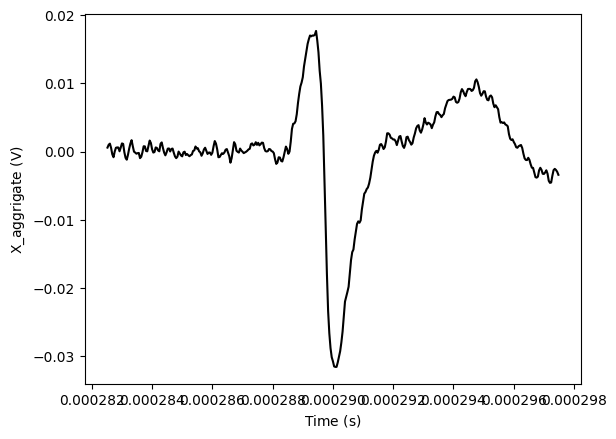

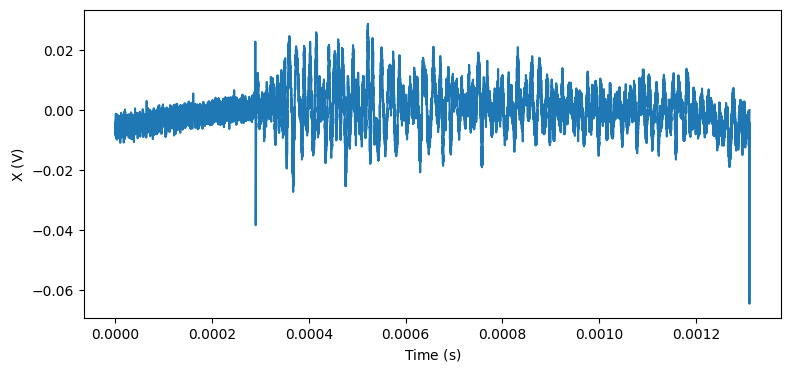

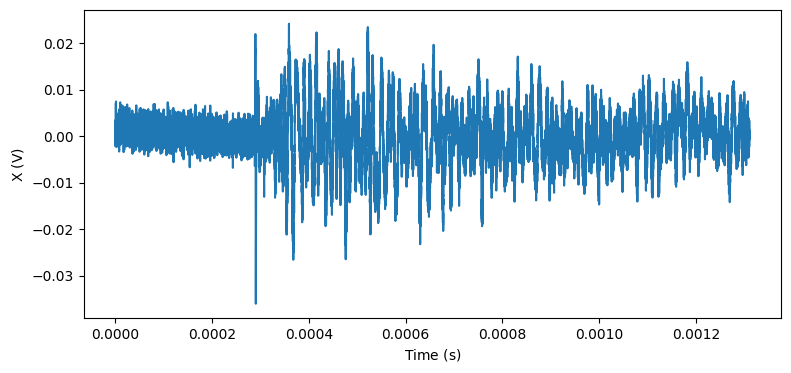

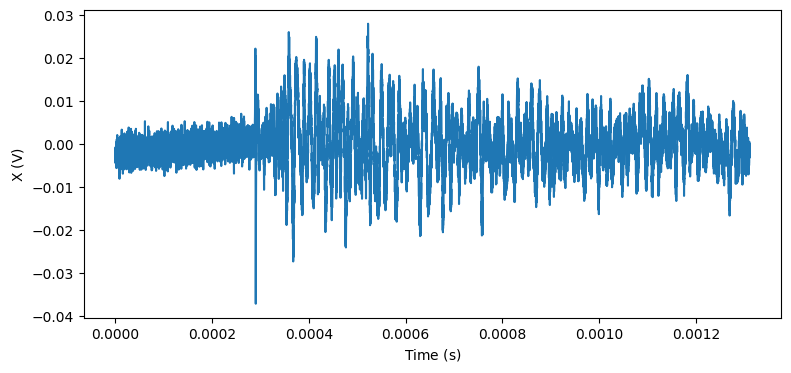

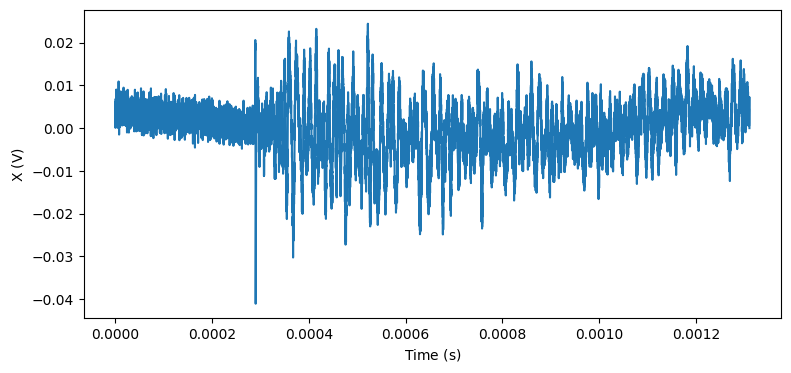

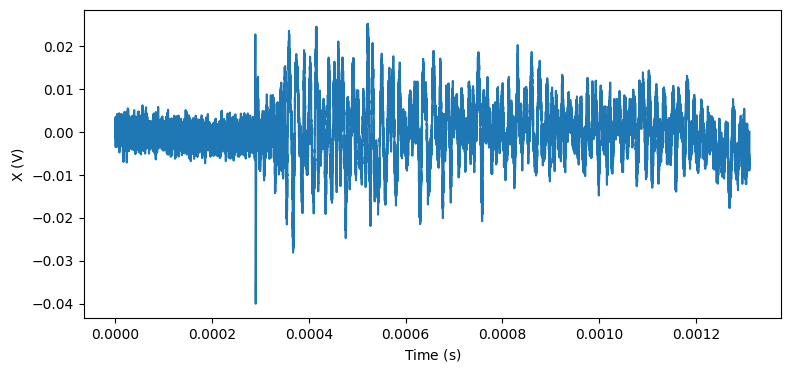

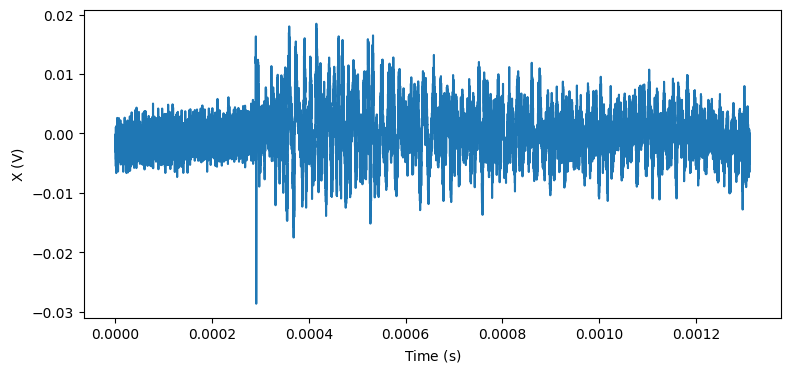

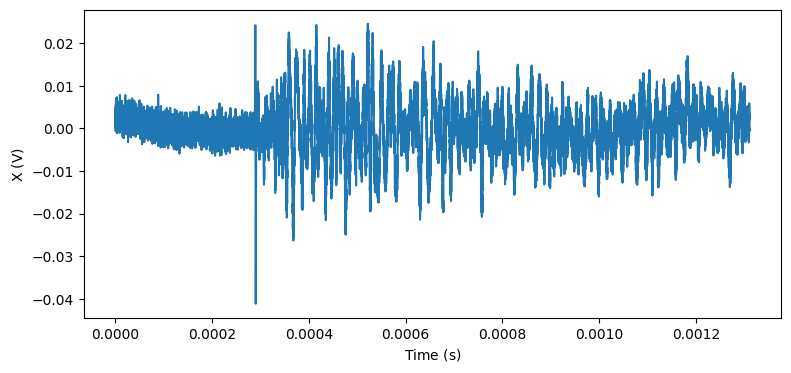

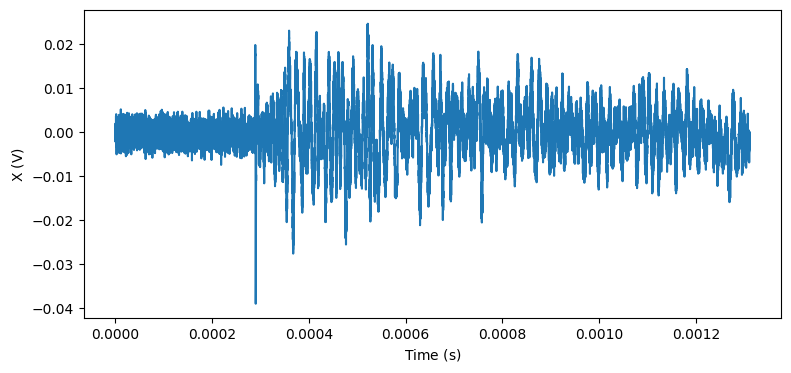

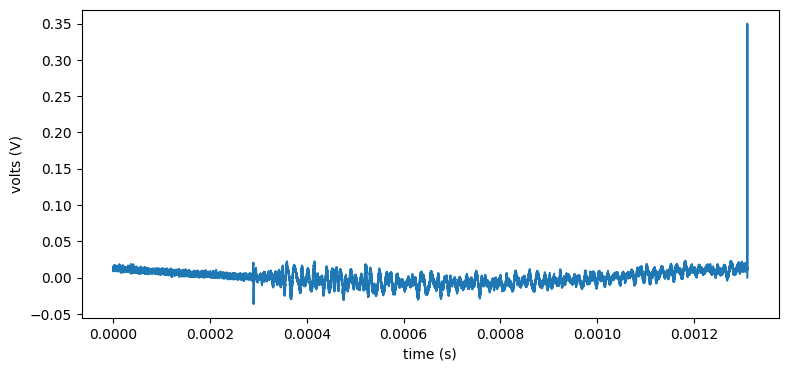

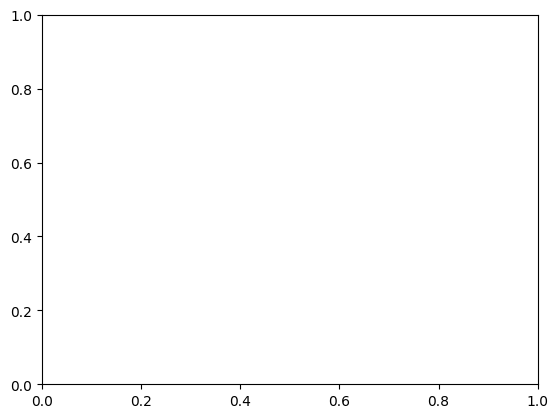

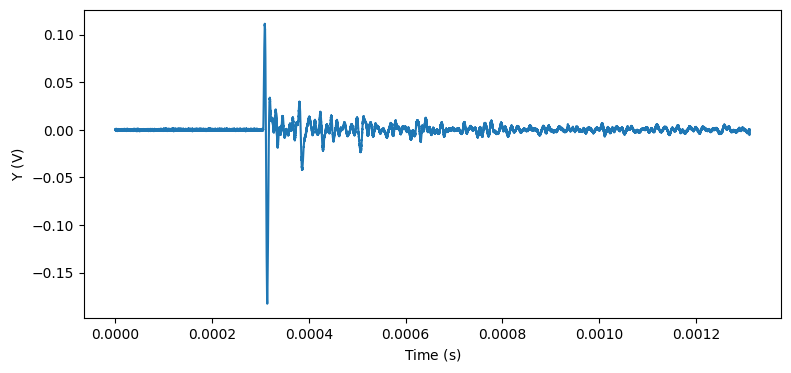

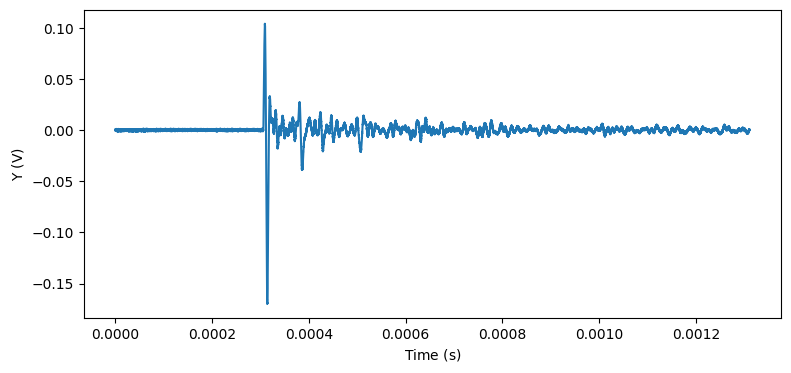

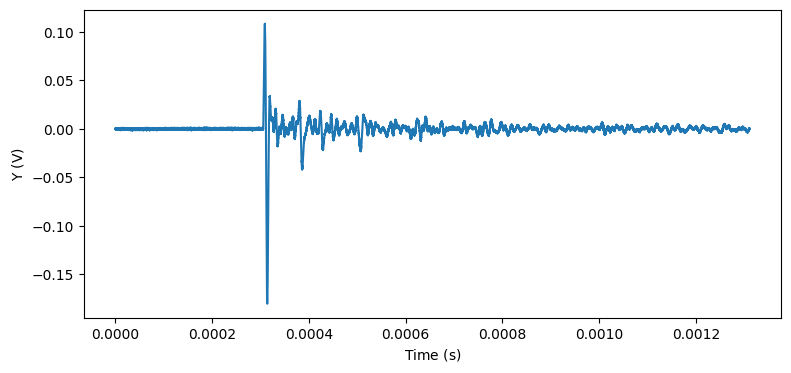

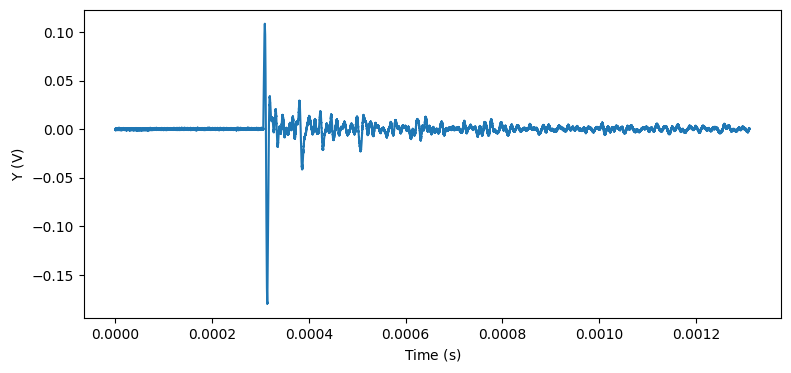

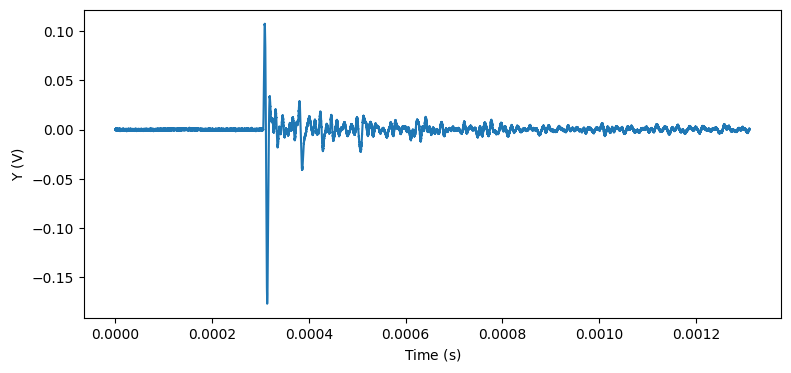

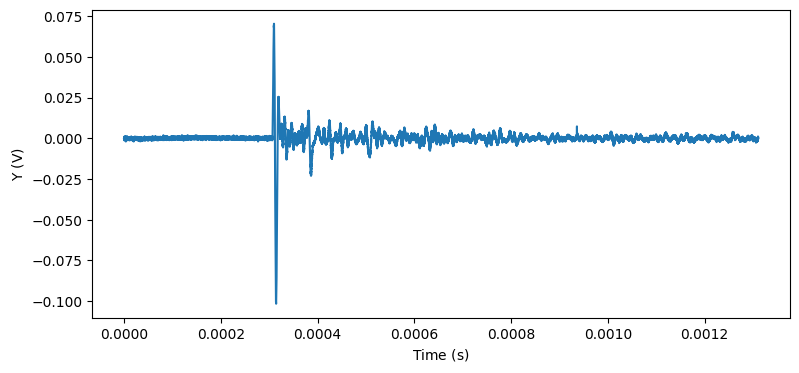

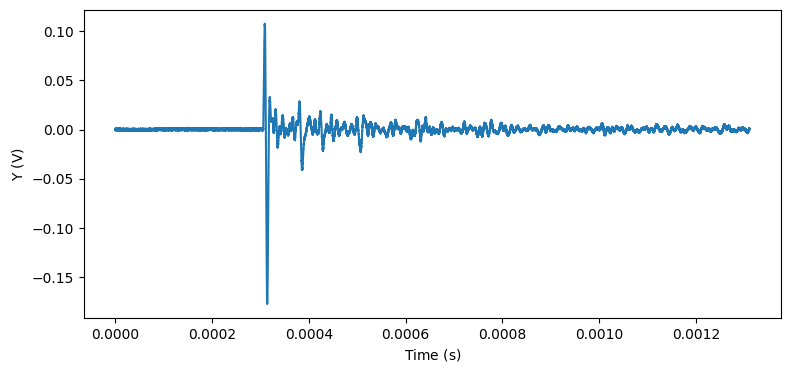

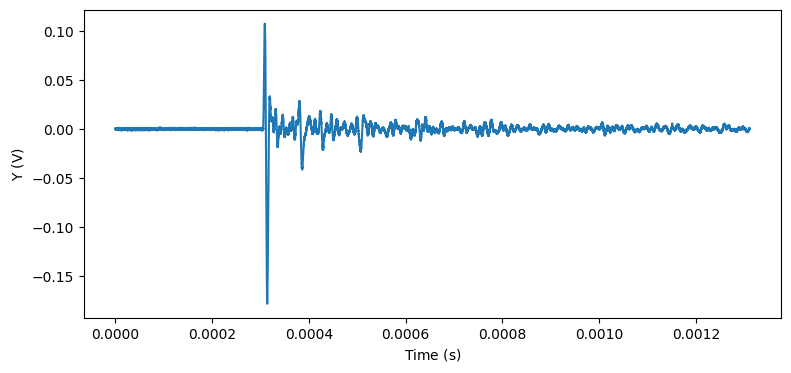

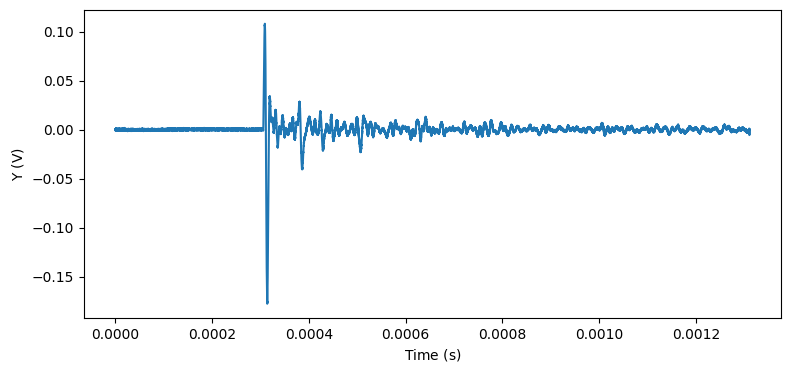

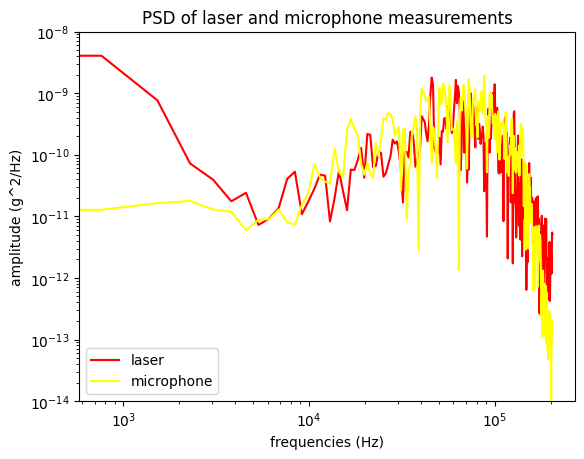

In [107]:
import numpy
import sys
sys.path.append("../../lhillber/brownian/src")
from time_series import CollectionTDMS as ctdms
import matplotlib.pyplot as plt

f = "data/20220511_laser_acoustic.tdms"
laser = ctdms(f)
laser.set_collection("X")
micro = ctdms(f)
micro.set_collection("Y")

laser.apply("calibrate", cal = -1, inplace = True)
laser.apply("detrend", mode = "linear", inplace = True)

# conversion factor 0.00068 V per pascal
fig, ax = plt.subplots(1, 1)

for s in laser.collection[2:]:
    run = s
    run.plot(tmin = 2.825e-4, tmax = 2.975e-4, ax = ax)

laser.aggrigate(collection_slice = slice(2, 11, 1))
laser.agg.plot(tmin = 2.825e-4, tmax = 2.975e-4, ax = ax, c = "k")

plt.xlabel("time (s)")
plt.ylabel("volts (V)")
plt.show()

micro.apply("detrend", mode = "constant", inplace = True)

fig, ax = plt.subplots(1, 1)

for s in micro.collection[2:]:
    run = s
    run.plot(tmin = 2.8e-4, tmax = 4e-4, ax = ax)

plt.show()

laser.apply("lowpass", cutoff = 2e5, inplace = True)
laser.apply("bin_average", Npts = laser.r / (2 * 200000), inplace = True)
micro.apply("lowpass", cutoff = 2e5, inplace = True)
micro.apply("bin_average", Npts = micro.r / (2 * 200000), inplace = True)
laser.average("PSD", taumax = 20e-3)
micro.average("PSD", taumax = 20e-3)

plt.loglog(laser.freq, laser.psd, color = "red")
plt.loglog(micro.freq, micro.psd, color = "yellow")
plt.title("PSD of laser and microphone measurements")
plt.xlabel("frequencies (Hz)")
plt.ylabel("amplitude (g^2/Hz)")
plt.legend(["laser", "microphone"], loc = "best")
plt.ylim([1e-14, 1e-8])
# plt.axvline(x = 2e5, color = "black")
plt.show()